# Fibers: Advanced

In this example a composite section is built by joining multiple basic shapes.

In [1]:
from xara.units.iks import inch, foot, ksi, kip 
# try:
#     from veux.canvas.config import beamer
# except:
#     pass
import matplotlib.pyplot as plt
import numpy as np
import veux

Save = False
group_colors = {
    "core":  "#D6D6D6", #"lightblue", 
    "cover": "#E6E6E6", #"lightgray", 
    "rebar": "#505050", # "#CD7D5B", # "#9c502D",
}

In [2]:
import xara
from xara import UniaxialMaterial

# Define materials
materials = {
    "core": UniaxialMaterial(
        type = "Concrete02",
        Fc  =   7.08*ksi,
        nu  =  0.2,
        ec0 =  0.00295,
        Fcu =  5*ksi,
        ecu =  0.014
    ),
    "cover": UniaxialMaterial(
        type = "Concrete02",
        Fc  =   -6*ksi,
        nu  =   0.2,
        ec0 =  -0.002,
        Fcu =  -0.5*ksi,
        ecu =  -0.005,
        # "lambda": 0.1,
        # "Ft": 0.65*ksi,
        # "Ets": 500. # Tension stiffening
    ),
    "rebar": UniaxialMaterial(
        type = "Steel01",
        nu = 0.3,
        E  =   29e3*ksi,
        Fy =     40*ksi,
        b =   0.05
    )
}

In [3]:
print(materials["core"].E)

4800.0


## Rectangle

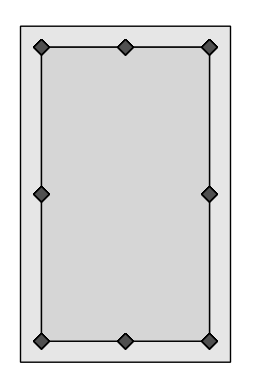

In [4]:
from xsection.library import Rectangle, Circle, HollowRectangle
from xsection import CompositeSection

h = 24
b = 15
d = 7/8
r = 0 #d/2

c = 1.5

bar = Circle(d/2, z=2, 
             material=materials["rebar"],
             mesh_scale=1/2, divisions=4, group="rebar")

cover = HollowRectangle(b, h, t=c, z=0, 
                        group="cover", 
                        mesh_scale=2,
                        material=materials["cover"]
)

core = Rectangle(b-2*c, h-2*c, z=1, 
                 group="core",
                 mesh_scale=c/(b-2*c),
                 material=materials["core"])

shape = CompositeSection([
            cover,
            core,
            *bar.linspace([-b/2+c+r, -h/2+c+r], [ b/2-c-r,-h/2+c+r], 3), # Top bars
            *bar.linspace([-b/2+c+r,        0], [ b/2-c-r,       0], 2), # Center bars
            *bar.linspace([-b/2+c+r,  h/2-c-r], [ b/2-c-r, h/2-c-r], 3)  # Bottom bars
        ], mesher="gmsh")



# veux.draw_shape(shape)

artist = veux.ShapeArtist(shape)
artist.draw_groups(legend=False, alpha=1, color_cycle=group_colors, legend_font={"fontsize": 20})
if Save:
    artist.save("img/fibers-1.png", dpi=300)

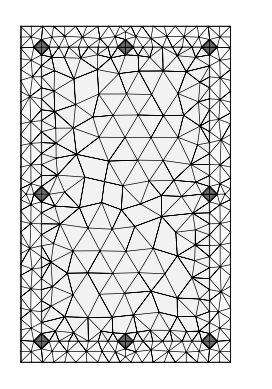

In [5]:
artist = veux.ShapeArtist(shape)
artist.draw_groups(legend=False, alpha=0.2, color_cycle=group_colors)
artist.draw_outlines()
artist.draw_exterior()

if Save:
    artist.save("img/fibers-2.png", dpi=300)

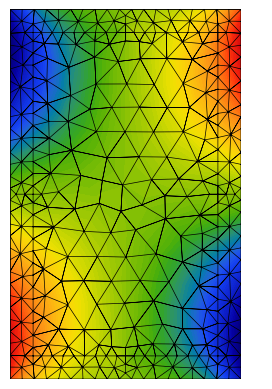

In [6]:
from xsection.analysis import WarpingAnalysis
# Warping analysis requires a constant representative Poisson ratio for the whole section.
wa = WarpingAnalysis(shape,nu=0.25)
artist = veux.ShapeArtist(shape)
artist.draw_surfaces(field=wa.solve_twist(), show_scale=False)
artist.draw_outlines()
artist.draw_exterior()

if Save:
    artist.save("img/fibers-3.png", dpi=300)

assert wa._nu == 0.25

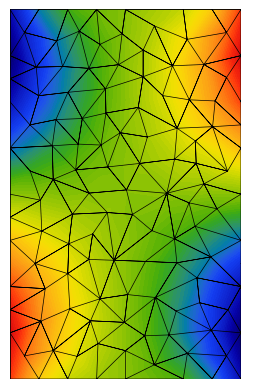

In [7]:
gross = Rectangle(b,h, material=materials["core"], mesh_scale=0.9*np.sqrt(d/h), group="core")
wa = WarpingAnalysis(gross)
artist = veux.ShapeArtist(gross)
artist.draw_surfaces(field=wa.solve_twist(), show_scale=False)
artist.draw_outlines()
artist.draw_exterior()

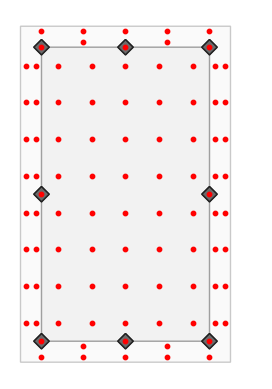

In [8]:
fibers = {
    "cover": {"d": 8, "t": 2, "b": 5},
    "core":  {"d": 8, "b": 5},
    "rebar": {"d": 1}
}


section = xara.Section("Fiber", shape, fibers=fibers)

artist = veux.ShapeArtist(section)
artist.draw_groups(legend=False, alpha=0.2, color_cycle=group_colors)
artist.draw_fibers(color="red")
if Save:
    artist.save("img/fibers-4.png", dpi=300)

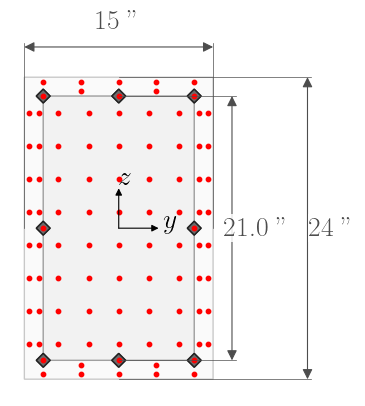

In [9]:

artist = veux.ShapeArtist(section)
artist.draw_groups(legend=False, alpha=0.2, color_cycle=group_colors)
artist.draw_fibers(color="red")

artist.draw_origin(label=("$y$","$z$"), fontsize=20)
artist.draw_dimensions({
    f"{h} \"":     (((0, -h/2), (0, h/2)), (b, 0), "inside"),
    f"{h-2*c} \"":   (((0, -(h/2-c)), (0, h/2-c)),  (b*0.6,  0), "inside"),
    f"{b} \"":     (((-b/2, 0), (b/2, 0)), (0, h*0.6), "inside")
}, gap=1,fontsize=20)

if Save:
    artist.save("img/fibers-5.png", dpi=300)
# artist.ax.figure.savefig("img/fiber-0004.png", dpi=300)

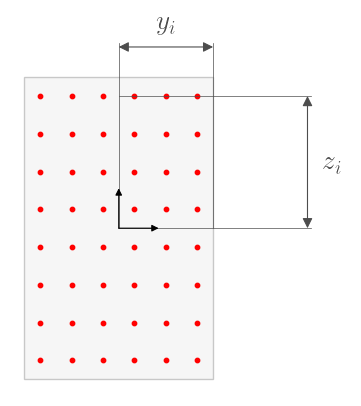

In [10]:
ogross = gross#.translate([3*b/2, 3*d/2])
gsection = xara.Section("Fiber", ogross, fibers={"d": 8, "b": 6})
artist = veux.ShapeArtist(gsection)
artist.draw_groups(legend=False, alpha=0.2, color_cycle=group_colors)
artist.draw_fibers(color="red")
# artist = veux.draw_shape(gross)
artist.draw_origin(fontsize=20) #label=("$y$","$z$")
artist.draw_dimensions({
    f"$z_i$":     (((0, 0), (0, h/2-h/(8)/2)), (b, 0), "inside"),
    f"$y_i$":     (((0, 0), (b/2, 0)), (0, h*0.6), "inside")
}, gap=1,fontsize=20)

# artist.ax.figure.savefig("img/fiber-0004.png", dpi=300)